# 📊 Internship Feedback Sentiment Analysis

## Objective

The objective of this project is to analyze internship feedback collected from interns and determine the sentiment of each feedback using Natural Language Processing (NLP). The feedback will be classified into **Positive**, **Neutral**, and **Negative** categories using the NLTK VADER Sentiment Analyzer.

---

## Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk

from nltk.sentiment import SentimentIntensityAnalyzer

## Download VADER Lexicon

In [2]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...


True

## Load the Dataset

In [3]:
import pandas as pd

df = pd.read_csv("intern_feedback.csv")

In [4]:
df.head()

,Feedback_ID,Intern_Name,Department,Mentor,Feedback,Rating,Source,Date
0,1,Waleed Ali,Web Development,Ayesha Ahmed,I really enjoyed working on real world project...,4,Email,2026-05-01
1,2,Rabia Ali,Machine Learning,Mehak Abbasi,This internship gave me a great foundation for...,4,LinkedIn,2026-05-03
2,3,Junaid Sheikh,Web Development,Rizwan Khan,The internship was neither good nor bad.,3,Google Form,2026-05-04
3,4,Zara Noor,Web Development,Mehak Abbasi,There was a lack of proper onboarding process.,1,Survey,2026-05-04
4,5,Amna Javed,Web Development,Ayesha Abbasi,The mentors were extremely supportive througho...,4,Survey,2026-05-06


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Feedback_ID  100 non-null    int64 
 1   Intern_Name  100 non-null    object
 2   Department   100 non-null    object
 3   Mentor       100 non-null    object
 4   Feedback     100 non-null    object
 5   Rating       100 non-null    int64 
 6   Source       100 non-null    object
 7   Date         100 non-null    object
dtypes: int64(2), object(6)
memory usage: 6.4+ KB


In [6]:
df.shape

(100, 8)

## Check Missing Values

In [7]:
df.isnull().sum()

Feedback_ID    0
Intern_Name    0
Department     0
Mentor         0
Feedback       0
Rating         0
Source         0
Date           0
dtype: int64

## Check Duplicate Records

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['Feedback_ID', 'Intern_Name', 'Department', 'Mentor', 'Feedback',
       'Rating', 'Source', 'Date'],
      dtype='object')

In [10]:
df.describe()

,Feedback_ID,Rating
count,100.000000,100.000000
mean,50.500000,3.350000
std,29.011492,1.313296
min,1.000000,1.000000
25%,25.750000,2.750000
50%,50.500000,3.500000
75%,75.250000,4.000000
max,100.000000,5.000000


## Initialize the Sentiment Analyzer

In [11]:
sia = SentimentIntensityAnalyzer()

## Test the Sentiment Analyzer

In [12]:
feedback = "The internship was amazing and I learned many new skills."

sia.polarity_scores(feedback)

{'neg': 0.0, 'neu': 0.678, 'pos': 0.322, 'compound': 0.5859}

## Create a Sentiment Classification Function

In [13]:
def get_sentiment(text):

    score = sia.polarity_scores(text)

    compound = score['compound']

    if compound >= 0.05:
        return "Positive"

    elif compound <= -0.05:
        return "Negative"

    else:
        return "Neutral"

## Apply Sentiment Analysis

In [14]:
df["Sentiment"] = df["Feedback"].apply(get_sentiment)

## Display Sentiment Analysis Results

In [15]:
df.head(10)

,Feedback_ID,Intern_Name,Department,Mentor,Feedback,Rating,Source,Date,Sentiment
0,1,Waleed Ali,Web Development,Ayesha Ahmed,I really enjoyed working on real world project...,4,Email,2026-05-01,Positive
1,2,Rabia Ali,Machine Learning,Mehak Abbasi,This internship gave me a great foundation for...,4,LinkedIn,2026-05-03,Positive
2,3,Junaid Sheikh,Web Development,Rizwan Khan,The internship was neither good nor bad.,3,Google Form,2026-05-04,Negative
3,4,Zara Noor,Web Development,Mehak Abbasi,There was a lack of proper onboarding process.,1,Survey,2026-05-04,Negative
4,5,Amna Javed,Web Development,Ayesha Abbasi,The mentors were extremely supportive througho...,4,Survey,2026-05-06,Positive
5,6,Noor Ali,UI/UX,Sara Rana,I expected a bit more but it was acceptable.,3,LinkedIn,2026-05-06,Positive
6,7,Nida Noor,Data Analytics,Iqra Abbasi,Overall this was a fantastic and enriching exp...,5,LinkedIn,2026-05-06,Positive
7,8,Sara Rana,UI/UX,Danish Baig,This internship was a turning point in my care...,4,Email,2026-05-08,Neutral
8,9,Amna Siddiqui,Data Analytics,Ayesha Abbasi,The company culture made me feel welcome from ...,4,LinkedIn,2026-05-08,Positive
9,10,Zain Baig,Data Analytics,Sara Rana,I appreciated the flexibility and support from...,4,LinkedIn,2026-05-10,Positive


## Count Sentiment Categories

In [16]:
df["Sentiment"].value_counts()

Sentiment
Positive    56
Neutral     26
Negative    18
Name: count, dtype: int64

## Visualize Sentiment Distribution (Bar Chart)

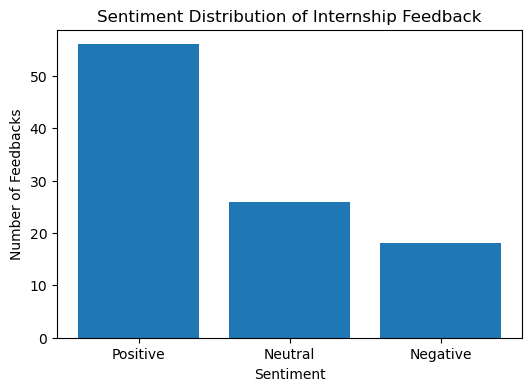

In [17]:
import matplotlib.pyplot as plt

sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Sentiment Distribution of Internship Feedback")

plt.xlabel("Sentiment")

plt.ylabel("Number of Feedbacks")

plt.show()

## Visualize Sentiment Distribution (Pie Chart)

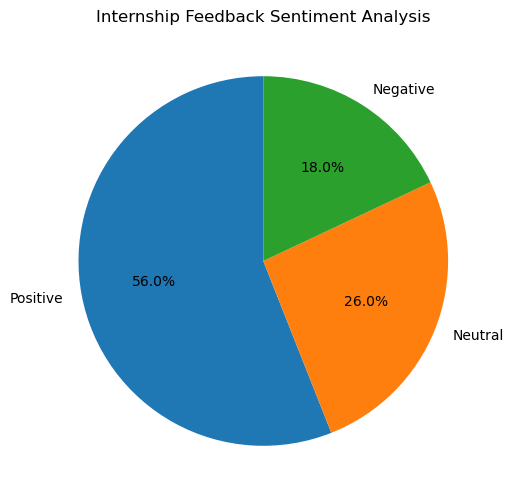

In [18]:
plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Internship Feedback Sentiment Analysis")

plt.show()

## Save the Final Dataset

In [19]:
df.to_csv("Sentiment_Result.csv", index=False)

print("File saved successfully!")

File saved successfully!


# Conclusion

In this project, internship feedback was analyzed using the NLTK VADER Sentiment Analyzer. Each feedback was successfully classified into Positive, Neutral, or Negative sentiment based on its emotional tone.

The analysis provides valuable insights into intern satisfaction and helps organizations identify strengths and areas for improvement. Data visualization further makes it easier to understand the overall sentiment distribution.

## Preview the Final Dataset

In [20]:
df.head(10)

,Feedback_ID,Intern_Name,Department,Mentor,Feedback,Rating,Source,Date,Sentiment
0,1,Waleed Ali,Web Development,Ayesha Ahmed,I really enjoyed working on real world project...,4,Email,2026-05-01,Positive
1,2,Rabia Ali,Machine Learning,Mehak Abbasi,This internship gave me a great foundation for...,4,LinkedIn,2026-05-03,Positive
2,3,Junaid Sheikh,Web Development,Rizwan Khan,The internship was neither good nor bad.,3,Google Form,2026-05-04,Negative
3,4,Zara Noor,Web Development,Mehak Abbasi,There was a lack of proper onboarding process.,1,Survey,2026-05-04,Negative
4,5,Amna Javed,Web Development,Ayesha Abbasi,The mentors were extremely supportive througho...,4,Survey,2026-05-06,Positive
5,6,Noor Ali,UI/UX,Sara Rana,I expected a bit more but it was acceptable.,3,LinkedIn,2026-05-06,Positive
6,7,Nida Noor,Data Analytics,Iqra Abbasi,Overall this was a fantastic and enriching exp...,5,LinkedIn,2026-05-06,Positive
7,8,Sara Rana,UI/UX,Danish Baig,This internship was a turning point in my care...,4,Email,2026-05-08,Neutral
8,9,Amna Siddiqui,Data Analytics,Ayesha Abbasi,The company culture made me feel welcome from ...,4,LinkedIn,2026-05-08,Positive
9,10,Zain Baig,Data Analytics,Sara Rana,I appreciated the flexibility and support from...,4,LinkedIn,2026-05-10,Positive


## Final Sentiment Summary

The following table shows the total number of Positive, Neutral, and Negative feedback records in the dataset.

In [21]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    56
Neutral     26
Negative    18
Name: count, dtype: int64
